In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar


In [4]:
sla = SLA(deg=0.25).da
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()
extent_mertz =[138.5,143,-67,-62]#-65.6]


In [5]:
pressure_axis = np.linspace(4,40,19)

In [7]:
meop=MEOP(extent=extent_mertz)
meop.load_profiles_for_spira(pressure_axis=pressure_axis)

100%|██████████| 82/82 [02:14<00:00,  1.64s/it]
/nfs/b0133/eejco/chapter_2/load_meop.py:114: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  self.ds = xr.Dataset.from_dict({


In [ ]:
elevation = GEBCO(coarsen_factor=40).ds.elevation
extent =[100,160,-69,-65.2]
shelf = Region('EA Shelf',extent,elevation_,min_elevation=-1000)
mertz = Region('Mertz',extent_mertz)

In [ ]:
meop.ds['elevation'] = elevation.interp(latitude=meop.ds.lat,longitude=meop.ds.lon).drop(['longitude','latitude'])
meop.ds['month'] = meop.ds.time.dt.month

In [ ]:
#remove summer
meop.df = meop.df[~meop.df.month.isin([1,2,3])]

In [15]:
meop_onshelf = meop.df[meop.df.elevation > -1000]
meop_offshelf = meop.df[meop.df.elevation < -1000]


In [27]:
meop.df

,platform,latitude,longitude,filename,temperature,salinity,gph,nlevels,month,elevation
time,,,,,,,,,,
2007-04-01 21:49:58,wd3-CTD2-07,-66.1926,140.4070,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.077880,19,4,<xarray.DataArray 'elevation' ()> Size: 8B\nar...
2007-04-02 03:00:00,wd3-CTD2-07,-66.2289,140.5210,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.047730,10,4,<xarray.DataArray 'elevation' ()> Size: 8B\nar...
2007-04-02 09:10:00,wd3-CTD2-07,-66.2993,140.9170,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.078880,19,4,<xarray.DataArray 'elevation' ()> Size: 8B\nar...
2007-04-02 15:00:00,wd3-CTD2-07,-66.3223,141.0130,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.049019,10,4,<xarray.DataArray 'elevation' ()> Size: 8B\nar...
2007-04-03 15:00:00,wd3-CTD2-07,-66.3215,141.0340,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.086452,19,4,<xarray.DataArray 'elevation' ()> Size: 8B\nar...
...,...,...,...,...,...,...,...,...,...,...
2019-06-08 07:49:59,wd11-768-18,-66.6608,141.3027,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.013696,36,6,<xarray.DataArray 'elevation' ()> Size: 8B\nar...
2019-06-08 23:09:59,wd11-768-18,-66.6508,141.3139,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.027960,16,6,<xarray.DataArray 'elevation' ()> Size: 8B\nar...
2019-06-09 15:50:00,wd11-768-18,-66.6525,141.3284,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.028732,16,6,<xarray.DataArray 'elevation' ()> Size: 8B\nar...


In [51]:
background_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

In [52]:
cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop,lag=0)

reindexing temps..


AttributeError: 'DataFrame' object has no attribute 'temperature'

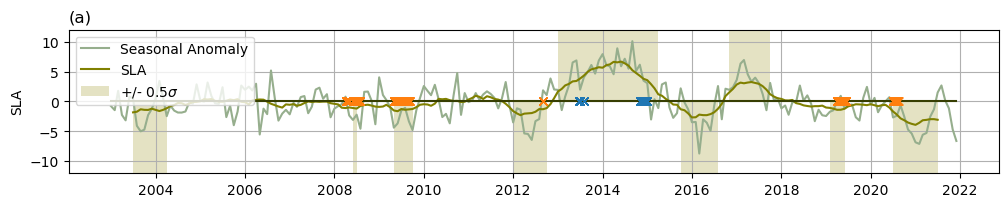

In [20]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')

In [26]:
cmp.s_pos.mean('pressure')

<xarray.DataArray 'PSAL_ADJUSTED' (time: 429)> Size: 3kB
array([33.67190712, 33.67696561, 33.70373856, 33.69734092, 33.68553061,
       33.62822141, 33.62331571, 33.63689061, 33.63541553, 33.64909262,
       33.67141563, 33.67025094, 33.64854331, 33.64728446, 33.65071568,
       33.66835785, 33.69780852, 33.79282299, 33.81371307, 33.80022872,
       33.78511188, 33.80571847, 33.73473358, 33.74310082, 33.74014744,
       33.72197964, 33.72537673, 33.7011526 , 33.70210848, 33.75159996,
       33.73975573, 33.66501638, 33.70027261, 33.70380843, 33.76175228,
       33.76768393, 33.75655767, 33.73934415, 33.72077018, 33.72425943,
       33.73057958, 33.7344521 , 33.74731044, 33.77085816, 33.84383533,
       33.8458527 , 33.81655322, 33.85749194, 33.84708666, 33.84313945,
       33.77968658, 33.82383708, 33.82189098, 33.81456897, 33.96646098,
       33.94866702, 33.9687757 , 33.95204424, 33.94198709, 33.94909407,
       33.94738127, 34.01118349, 34.02525771, 34.02501939, 34.00671407,
       34.0494959 , 34.03778116, 34.07474799, 34.10865121, 34.06611593,
       34.14617217, 34.12721935, 34.13173113, 34.13609194, 34.03925906,
       34.07749758, 34.01538126, 33.96818643, 33.97421767, 33.97595355,
       33.92588204, 33.96749015, 33.97229867, 34.33581975, 34.35857743,
       34.39598605, 34.41650531, 34.35925976, 34.42890227, 34.38855723,
       34.43484256, 34.43594662, 34.42856397, 34.42012827, 34.41541612,
       34.36668506, 34.45079625, 34.37777349, 34.38168771, 34.43166532,
...
       34.55878687, 34.55539179, 34.53006303, 34.23171455, 34.23829199,
       34.55878687, 34.55535674, 34.53111699, 34.55726933, 34.29204921,
       34.53177703, 34.55535674, 34.2220463 , 34.551729  , 34.52839088,
       34.53425229, 34.3130191 , 34.32878285, 34.5333276 , 34.53577042,
       34.55301235, 34.16687142, 34.52551039, 34.5180913 , 34.56842434,
       34.18011284, 34.23970258, 34.30332438, 34.55674844, 34.55805437,
       34.53984523, 34.55805437, 34.33115688, 34.31237858, 34.21914875,
       34.54364947, 34.57134068, 34.56321827, 34.21200844, 34.54544519,
       34.28557336, 34.54093291, 34.54837669, 34.56892977, 34.53943333,
       34.2660395 , 34.55805437, 34.5381276 , 34.56392634, 34.19459835,
       34.55558656, 34.56392634, 34.56792581, 34.20034027, 34.54950092,
       34.26222932, 34.57017979, 34.53863716, 34.2155049 , 34.54885653,
       34.56250262, 34.54576151, 34.53811324, 34.55857277, 34.21486905,
       34.22826764, 34.55563997, 34.56291163, 34.56671865, 34.53563028,
       34.56328619, 34.13250232, 34.5526935 , 34.16220002, 34.5574801 ,
       34.55376339, 34.55291146, 34.5676653 , 34.55666018, 34.55619176,
       34.55594977, 34.56251538, 34.54847828, 34.55766919, 34.53497545,
       34.50714162, 34.55638604, 34.56471241, 34.56840372, 34.54910288,
       34.55435803, 34.55666018, 34.5313282 , 34.5592828 , 34.55984497,
       34.56042445, 34.54830913, 34.5636477 , 34.53580816])
Coordinates:
  * time     (time) datetime64[ns] 3kB 2013-06-19T07:31:25 ... 2014-12-31T23:...